<a href="https://colab.research.google.com/github/TechdevwebMSU/Student-Performance-Prediction/blob/main/Student_Performance_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


🔹 Average final grade by gender:
  sex  avg_final_grade
0   F         9.966346
1   M        10.914439

🔹 Student count by study time and failure count:
    studytime  failures  student_count
0           2         0            158
1           1         0             74
2           3         0             54
3           2         1             26
4           4         0             26
5           1         1             16
6           1         3              9
7           2         2              7
8           2         3              7
9           3         1              7
10          1         2              6
11          3         2              4
12          4         1              1

🎯 Model Accuracy: 0.9367088607594937
              precision    recall  f1-score   support

        High       0.86      0.75      0.80         8
         Low       0.97      0.97      0.97        37
      Medium       0.91      0.94      0.93        34

    accuracy                           0.94  

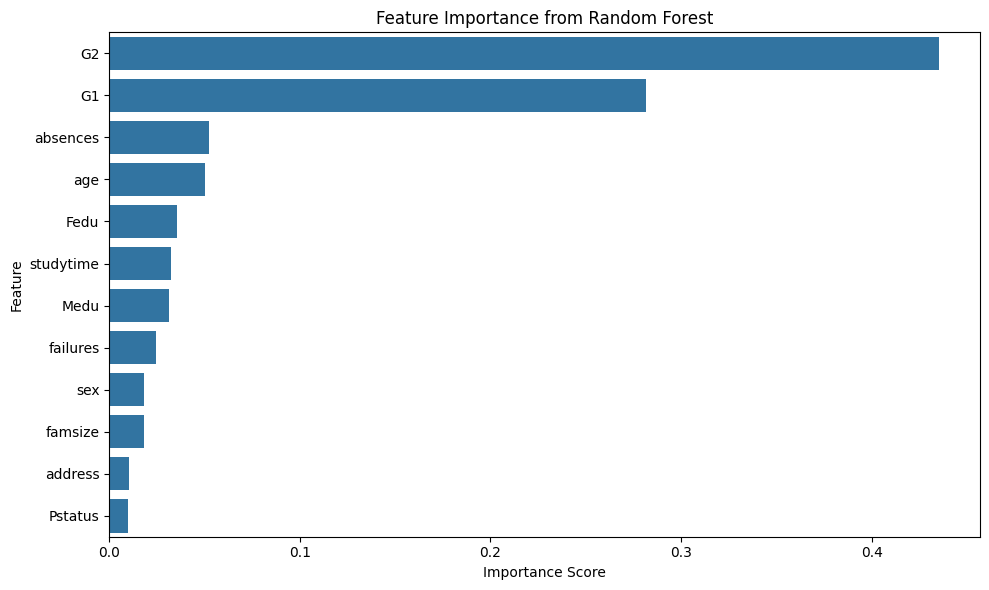

In [1]:


# Step 1: Import Libraries
import pandas as pd
import numpy as np
import sqlite3
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Load Dataset
df = pd.read_csv("student-mat.csv", sep=';')  # Dataset with ';' delimiter

# Step 3: Store dataset into SQLite
conn = sqlite3.connect("students.db")
df.to_sql("student_data", conn, if_exists="replace", index=False)

# Step 4: SQL Queries for EDA
print("\n🔹 Average final grade by gender:")
query1 = "SELECT sex, AVG(G3) AS avg_final_grade FROM student_data GROUP BY sex;"
print(pd.read_sql_query(query1, conn))

print("\n🔹 Student count by study time and failure count:")
query2 = """
SELECT studytime, failures, COUNT(*) as student_count
FROM student_data
GROUP BY studytime, failures
ORDER BY student_count DESC;
"""
print(pd.read_sql_query(query2, conn))

# Step 5: Create SQL View for ML-ready data
conn.execute("""
CREATE VIEW IF NOT EXISTS ml_ready_data AS
SELECT sex, age, address, famsize, Pstatus, Medu, Fedu, studytime,
       failures, absences, G1, G2, G3
FROM student_data
WHERE G3 IS NOT NULL;
""")

# Step 6: Load SQL View into DataFrame
df = pd.read_sql_query("SELECT * FROM ml_ready_data", conn)

# Step 7: Encode categorical variables
label_encoders = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Step 8: Define Target variable: performance category based on G3
df['performance'] = pd.cut(df['G3'], bins=[-1, 10, 15, 20], labels=["Low", "Medium", "High"])
df.drop('G3', axis=1, inplace=True)

# Step 9: Train-Test Split
X = df.drop('performance', axis=1)
y = df['performance']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Step 10: Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 11: Train RandomForest Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Step 12: Evaluate Model
y_pred = model.predict(X_test)
print("\n🎯 Model Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Step 13: Feature Importance Plot
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=importances.index)
plt.title("Feature Importance from Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

